# 01 - Análisis Exploratorio de Datos (EDA)
**Dataset:** Sloan Digital Sky Survey - Data Release 17 (SDSS DR17).

**Objetivo:** Comprender la estructura, variabilidad, sesgos y relaciones internas de las variables astronómicas antes de la fase de preprocesamiento.

In [1]:
# Importación de librerías
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

---  
## 1.1. Carga de Datos y Estructura Inicial

En este paso inicial realizamos la inspección dimensional del dataset en crudo. El dataset original SDSS DR17 contiene 100,000 registros astronómicos y 18 columnas que vamos a estructurar según su función dentro del pipeline no supervisado.

In [2]:
# Descargar del directorio del dataset
dataset_dir = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

# Ruta del dataset
file_path = os.path.join(dataset_dir, "star_classification.csv")

# Cargar dataset
df_raw = pd.read_csv(file_path)

# Inspección de dimensiones
print(f"Dimensiones del dataset original: {df_raw.shape[0]} registros, {df_raw.shape[1]} columnas.")
print("\n--- Tipos de datos y nulos ---")
print(df_raw.info())

# Visualizar primeras filas
df_raw.head()

100%|██████████| 6.89M/6.89M [00:01<00:00, 4.54MB/s]

Extracting files...


Dimensiones del dataset original: 100000 registros, 18 columnas.

--- Tipos de datos y nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          1

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


### **Fundamento Teórico y Clasificación de Columnas**

#### **1. Coordenadas Ecuatoriales (Posición Astronómica)**
Proyecciones de latitud y longitud sobre la esfera celeste:
* **`alpha` (Ascensión Recta):** Equivale a la *longitud* celeste, medida en grados ($0^\circ$ a $360^\circ$) desde el Punto Aries.
* **`delta` (Declinación):** Equivale a la *latitud* celeste, medida en grados ($-90^\circ$ a $+90^\circ$) desde el ecuador celeste.

Se clasifican como datos de posición espacial. Se descartan para la caracterización física de los cuerpos celestes.

#### **2. Filtros del Sistema $ugriz$**

El telescopio del SDSS utiliza 5 filtros diferentes para separar la luz que recibe en 5 *bandas* según su longitud de onda ($\lambda$), desde el ultravioleta hasta el infrarrojo.

| Banda / Filtro | Longitud de onda ($\lambda$) | Tipo de luz | ¿Qué tipo de objetos/fenómenos mide mejor? |
| :---: | :---: | :---: | :--- |
| **u** | $\sim 355.1\text{ nm}$ | Ultravioleta | Objetos extremadamente calientes: estrellas masivas jóvenes (como las estrellas de tipo espectral O/B) y los cuásares masivos. |
| **g** | $\sim 468.6\text{ nm}$ | Verde / Azul | Estrellas de temperatura media (como nuestro Sol) y la luz general acumulada de las galaxias. |
| **r** | $\sim 616.5\text{ nm}$ | Rojo | Banda de referencia principal. Mide muy bien la radiación del hidrógeno ($\text{H}\alpha$). |
| **i** | $\sim 748.1\text{ nm}$ | Infrarrojo cercano | Estrellas viejas y frías, además de atravesar el polvo cósmico que bloquea la luz visible. |
| **z** | $\sim 893.1\text{ nm}$ | Infrarrojo más lejano | Cuásares y galaxias muy lejanas cuya luz original se ha estirado hacia el infrarrojo por la expansión del universo. |
<break>

**Magnitudes Fotométricas ($m_{AB}$)**

La **magnitud** es una forma de medir cómo de brillante es un objeto celeste observado desde la Tierra, el SDSS utiliza el sistema fotométrico AB para medir cuánta luz (flujo de fotones, $f_\nu$) llega al detector en las 5 bandas específicas del espectro electromagnético, en escala logarítmica inversa:

$$m_{AB} = -2.5 \cdot \log_{10}\left(\frac{f_\nu}{3631 \text{ Jy}}\right)$$

Al ser una escala inversa, a menor valor de magnitud, más brillante es el objeto. Un valor alto de magnitud significa que la fuente de luz es muy tenue o débil.

El **sistema AB** es un estándar internacional donde se toma como referencia fija un flujo de energía constante ($3631\text{ Jy}$, janskys). Esto permite que las observaciones de distintos telescopios sean comparables.

#### **3. Desplazamiento al rojo: `redshift` ($z$):**
* Mide el estiramiento de la longitud de onda de la luz por el *efecto Doppler* y la expansión cosmológica del universo:

$$z = \frac{\lambda_{\text{observada}}}{\lambda_{\text{emitida}}}-1$$

  * **Estrellas (`STAR`):** $z \approx 0$ (generalmente $-0.004 \le z \le 0.004$, dentro de la Vía Láctea). . No sufren expansión cosmológica.
  * **Galaxias (`GALAXY`):** $0.001 < z < 0.8$ (sistemas extragalácticos a distancias intermedias).
  * **Cuásares (`QSO`):** $0.1 < z < 7.0+$ (fuentes ultra-luminosas situadas en los confines del universo observable).

#### **4. Variable Objetivo: `class`**
Según el valor espectroscópico se clasifica en tres categorías:
* `GALAXY`: Sistemas estelares masivos y extendidos.
* `STAR`: Estrellas individuales de nuestra propia galaxia.
* `QSO`: Cuásares (Quasi-Stellar Object), núcleos galácticos activos hiper-luminosos alimentados por agujeros negros supermasivos.

Se elimina del espacio de características $X$. Se extrae y almacena aislada en el vector $\mathbb{y}$ **únicamente para la evaluación y validación externa** posterior del clustering.

#### **5. Identificadores Instrumentales y Metadatos**
Estas 9 columnas son parámetros técnicos de las placas metálicas, cámaras CCD y ejecuciones de software del observatorio SDSS. No contienen propiedades físicas de las estrellas/galaxias y deben eliminarse para evitar ruido.

| Variable | Nombre | Descripción |
| --- | --- | --- |
| `obj_ID` | Object Identifier | Identificador único del objeto astronómico en la base de datos fotométrica de SDSS. |
| `run_ID` | Run Number | Número de la pasada o barrido que realizó el telescopio Apache Point sobre esa franja del cielo. |
| `rerun_ID` | Rerun Number | Número de reprocesamiento del software de reducción de imagen. |
| `cam_col` | Camera Column | Columna de la cámara CCD (del 1 al 6) sobre la que cayó la imagen del objeto. |
| `field_ID` | Field Number | Número de fotograma individual dentro de la pasada de la cámara. |
| `spec_obj_ID` | Spectroscopic Object ID | Identificador único de la observación espectroscópica en el catálogo. |
| `plate` | Plate ID | Número de la placa metálica física perforada mediante fibra óptica para capturar los espectros . |
| `MJD` | Modified Julian Date | Fecha juliana modificada en la que se tomó la espectrosopia. $MJD = \text{JD} - 2400000.5$. |
| `fiber_ID` | Fiber ID | Número del cable de fibra óptica (de 1 a 640 o 1000) conectado al espectrógrafo en esa placa. |
<break>

En resumen:
* **Eliminación** de 11 columnas: 2 coordenadas (`alpha`, `delta`), 9 metadatos operativos del telescopio.
* **Ocultación** de la variable objetivo `class`.
* **Conservación** de las 6 variables continuas: `u`, `g`, `r`, `i`, `z`, `redshift`.

In [3]:
# Eliminación y aislamiento de variables
ID_COLS = ['obj_ID', 'alpha', 'delta', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']
TARGET_COL = 'class'

print("--- Distribucíon de la variable objetivo (class) ---")
print((df_raw[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# Separación para el EDA
y = df_raw[TARGET_COL].copy()
X_eda = df_raw.drop(columns=ID_COLS + [TARGET_COL])

print(f"\nDimensiones del dataset para el EDA: {X_eda.shape}")

--- Distribucíon de la variable objetivo (class) ---
class
GALAXY    59.44%
STAR      21.59%
QSO       18.96%
Name: proportion, dtype: object

Dimensiones del dataset para el EDA: (100000, 6)


---  
## 1.2. Evaluación de la Calidad de los Datos

Para garantizar un preprocesamiento riguroso, evaluamos la integridad de los datos y la presencia de lecturas erróneas causadas por saturación o fallos en los sensores CCD del telescopio.

### 1.2.1. Valores Nulos
* En el dataset SDSS DR17 no hay registros vacíos (NaN).

In [4]:
# Comprobación de Nulos
nulos_totales = X_eda.isnull().sum().sum()
print(f"Total de valores nulos en el dataset: {nulos_totales}")

Total de valores nulos en el dataset: 0


### 1.2.2. Lecturas Aberrantes. Tratamiento de Errores Instrumentales
* Los sensores CCD de los telescopios sufren a veces saturación o pérdida de señal, registrando valores anómalos como magnitudes extremas negativas.
* En el sistema fotométrico astronómico $AB$, valores $\le 0$ (como $-9999$) representan errores instrumentales o pérdida de señal en la toma del espectro.
* **Filtro de Limpieza** propuesto para el preprocesamiento: $u, g, r, i, z > 0$.

In [5]:
# Detección de lecturas físicas aberrantes (magnitudes <= 0)
aberrant_readings = (X_eda[['u', 'g', 'r', 'i', 'z']] <= 0).sum()
print("\nNúmero de lecturas fotométricas <= 0 (Errores de sensor CCD):")
print(aberrant_readings)

# Aplicar filtro de prueba para EDA
mask_valid = (X_eda['u'] > 0) & (X_eda['g'] > 0) & (X_eda['r'] > 0) & (X_eda['i'] > 0) & (X_eda['z'] > 0)
X_clean = X_eda[mask_valid].copy()

print(f"\nRegistros descartados por saturación: {len(X_eda) - len(X_clean)} ({((len(X_eda) - len(X_clean))/len(X_eda))*100:.3f}%)")
print(f"Registros válidos conservados: {len(X_clean)}")


Número de lecturas fotométricas <= 0 (Errores de sensor CCD):
u    1
g    1
r    0
i    0
z    1
dtype: int64

Registros descartados por saturación: 1 (0.001%)
Registros válidos conservados: 99999


---  
## 1.3. Análisis Univariante

### 1.3.1. Estadísticos descriptivos
Análisis de medidas de tendencia central, dispersión, asimetría y presencia de *outliers* en las 6 variables continuas.


In [6]:
# Obtener las estadísticos base
stats = X_clean.describe().copy()

# Agregar coeficiente de asimetría
stats.loc['skew'] = X_clean.skew()

display(stats.T.round(2))

,count,mean,std,min,25%,50%,75%,max,skew
u,99999.0,22.08,2.25,11.00,20.35,22.18,23.69,32.78,-0.07
g,99999.0,20.63,2.04,10.50,18.97,21.10,22.12,31.60,-0.43
r,99999.0,19.65,1.85,9.82,18.14,20.13,21.04,29.57,-0.51
i,99999.0,19.08,1.76,9.47,17.73,19.41,20.40,32.14,-0.40
z,99999.0,18.77,1.77,9.61,17.46,19.00,19.92,29.38,-0.26
redshift,99999.0,0.58,0.73,-0.01,0.05,0.42,0.70,7.01,2.52


### 1.3.2. Distribución de Variables

#### Magnitudes $u, g, r, i, z$:
* Muestran distribuciones unimodales y bimodal-asimétricas con una ligera **asimetría negativa**, con coeficientes que van desde $-0.07$ en la banda `u` hasta $-0.51$ en la banda `r`.
* Presentan una concentración principal de datos en magnitudes tenues (aproximadamente entre $18$ y $23 \text{ } m_{AB}$), observándose en bandas como `g`, `r`, `i` y `z` un segundo pico alrededor de magnitudes más brillantes ($16 - 18 \text{ } m_{AB}$).
* Existe un solapamiento masivo de rangos de valores entre magnitudes adyacentes, lo que refleja su alta colinealidad.

#### Variable `redshift`:

* Presenta una **asimetría positiva** elevada con un coeficiente de **$2.52$**.
* Muestra una concentración muy alta en valores cercanos a $z \approx 0$ (estrellas de la Vía Láctea y galaxias cercanas), representada en la gráfica mediante **escala logarítmica** para poder visibilizar la larga cola de cuásares y objetos lejanos que se extiende desde $z > 1$ hasta $z \approx 7$.
* La asimetría y diferencia de comportamiento frente al rango de las magnitudes ($10$ a $30 \text{ } m_{AB}$) hace que el **escalado** de variables sea un requisito obligatorio para evitar distorsiones en el cálculo de distancias euclídeas.

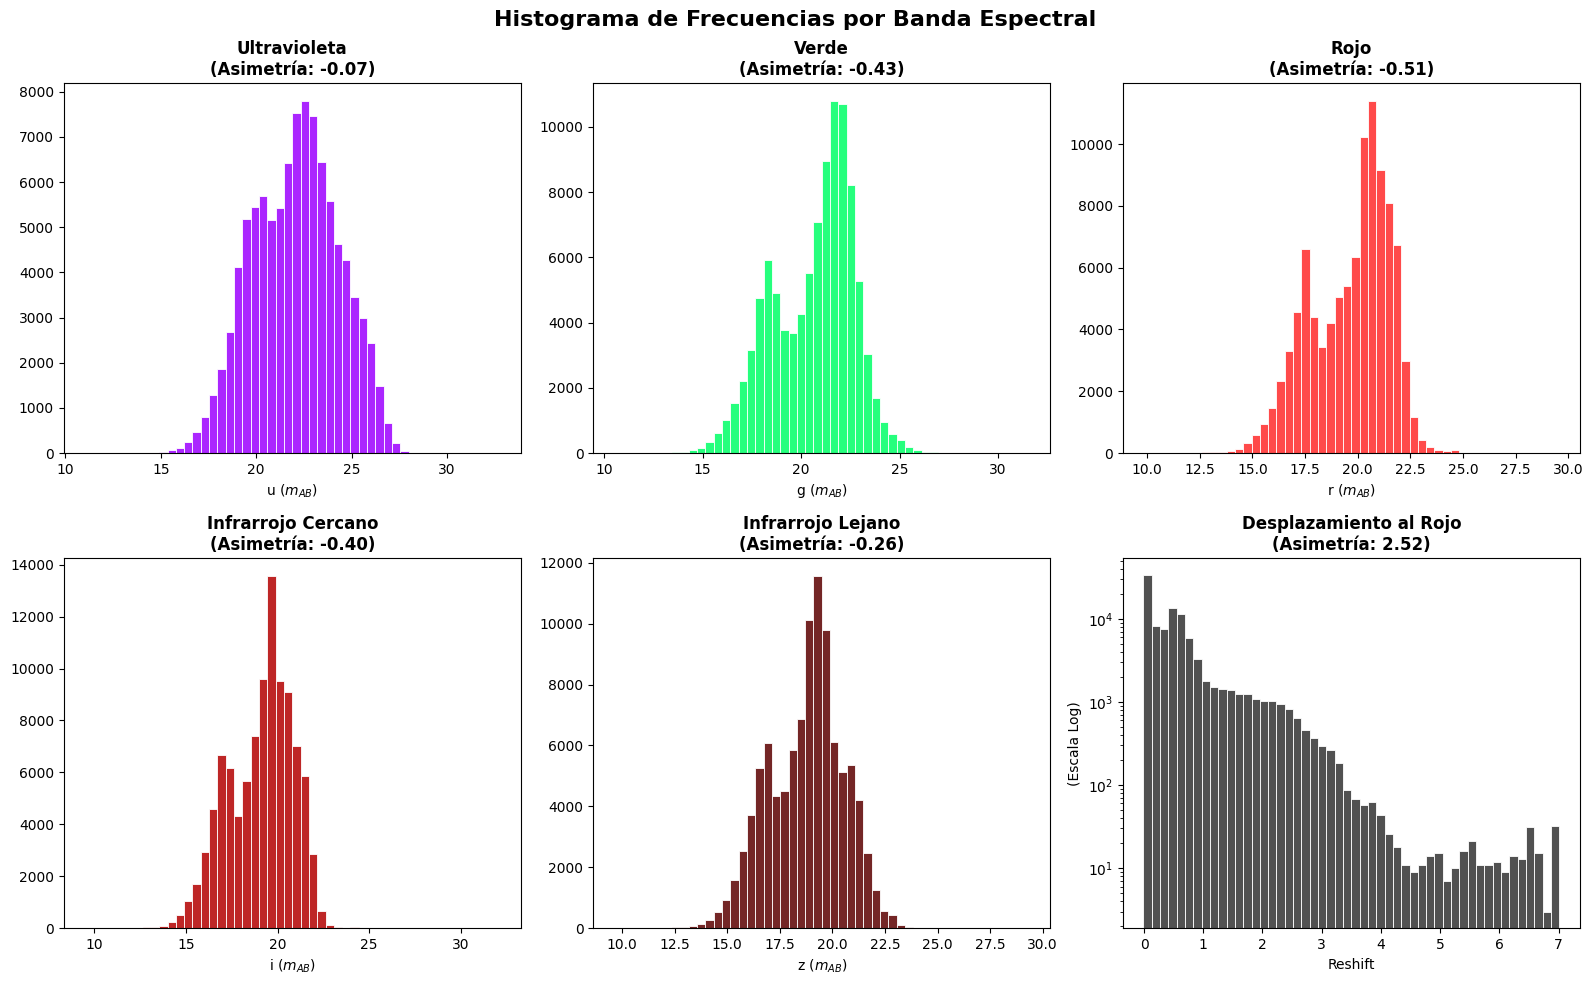

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features = ['u', 'g', 'r', 'i', 'z', 'redshift']
names = [
    'Ultravioleta',
    'Verde',
    'Rojo',
    'Infrarrojo Cercano',
    'Infrarrojo Lejano',
    'Desplazamiento al Rojo'
]

# Unidades para el eje X
units = [
    'u ($m_{AB}$)',
    'g ($m_{AB}$)',
    'r ($m_{AB}$)',
    'i ($m_{AB}$)',
    'z ($m_{AB}$)',
    'Reshift'
]

colors = [
    '#9d00ff',  # u
    '#00ff66',  # g
    '#ff2a2a',  # r
    '#b30000',  # i
    '#5c0000',  # z
    '#333333'   # redshift
]

for i, (col, name, unit, color) in enumerate(zip(features, names, units, colors)):
    sns.histplot(
        X_clean[col],
        ax=axes[i],
        color=color,
        bins=50,
        edgecolor='white',
        linewidth=0.6,
        alpha=0.85
    )
    axes[i].set_title(f"{name}\n(Asimetría: {X_clean[col].skew():.2f})", fontweight='bold')

    # Asignar la unidad al eje X y quitar el texto por defecto del eje Y
    axes[i].set_xlabel(unit)
    axes[i].set_ylabel("")

    # Configuración especial para redshift
    if col == 'redshift':
        axes[i].set_yscale('log')  # Escala logarítmica para apreciar la cola larga de Cuásares
        axes[i].set_ylabel("(Escala Log)")

plt.suptitle("Histograma de Frecuencias por Banda Espectral", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3.3. Tratamiento de Outliers
* Los valores atípicos no se descartan de manera arbitraria, sino que se evalúan en función de su contexto.
* En astronomía los valores extremos en `redshift` ($z > 3$) o con un brillo atípico en la banda ultravioleta $u$ **no son errores de medición, sino fuentes astrofísicas de alta energía (cuásares lejanos o supernovas)**.
* **Estrategia:** Conservar los *outliers* reales y aislarlos posteriormente mediante algoritmos basados en densidad (DBSCAN).

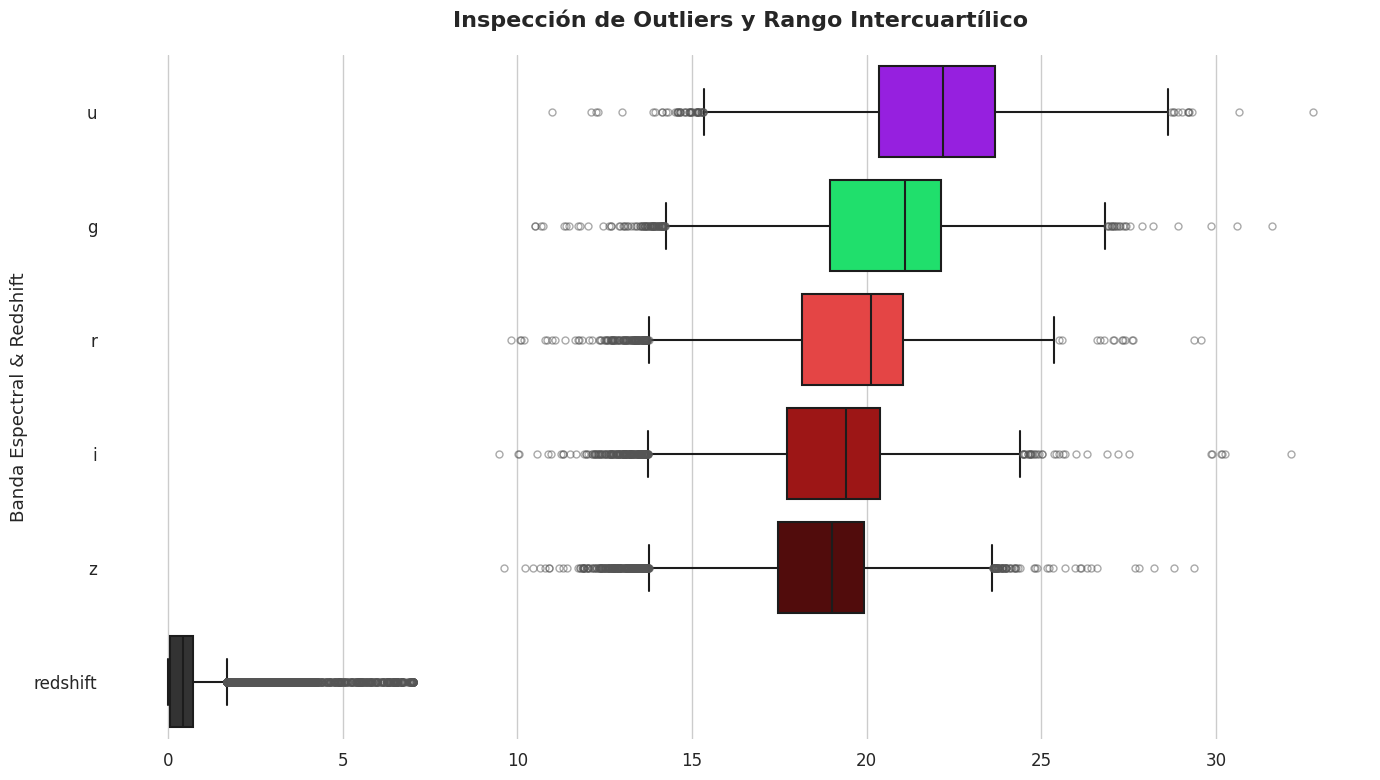

In [8]:
# Configurar tema
sns.set_theme(style="whitegrid", font_scale=1.1)

# Colores
colors = [
    '#9d00ff',  # u
    '#00ff66',  # g
    '#ff2a2a',  # r
    '#b30000',  # i
    '#5c0000',  # z
    '#333333'   # redshift
]

plt.figure(figsize=(14, 8))

# Boxplot
ax = sns.boxplot(
    data=X_clean,
    orient="h",
    palette=colors,
    linewidth=1.5,
    fliersize=5,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'none',
        'markeredgecolor': '#555555',
        'alpha': 0.5
    }
)

# Títulos y etiquetas
plt.title(
    "Inspección de Outliers y Rango Intercuartílico",
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel("")
plt.ylabel("Banda Espectral & Redshift")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

---  
## 1.4. Análisis Multivariante

Evaluamos las relaciones entre pares de variables para detectar **multicolinealidad** y justificar la necesidad de reducir la dimensionalidad:

* **Multicolinealidad extrema en magnitudes adyacentes ($\ge 0.92$):** Se observan correlaciones muy elevadas entre filtros contiguos, destacando especialmente los pares **`i` con `z` ($r = 0.97$)**, **`r` con `i` ($r = 0.96$)**, **`g` con `r` ($r = 0.93$)** y **`r` con `z` ($r = 0.92$)**.
* **Gradiente de correlación respecto a la distancia espectral:** La fuerza de la correlación disminuye progresivamente a medida que las bandas se alejan en el espectro electromagnético, pasando de $r = 0.85$ entre `u` y `g` hasta caer a $r = 0.55$ entre los extremos `u` (ultravioleta) y `z` (infrarrojo lejano).
* **Baja correlación del `redshift`:** La variable `redshift` mantiene correlaciones moderadas-bajas con las magnitudes fotométricas, oscilando entre $r = 0.17$ (con `u`) y $r = 0.50$ (con `z`).
* **Análisis de Componentes Principales (PCA):** La fuerte redundancia de información entre las 5 bandas fotométricas justifica el uso del PCA para proyectar estas variables correlacionadas en un nuevo espacio ortogonal, eliminando la colinealidad y reteniendo la mayor cantidad de varianza en pocas dimensiones.

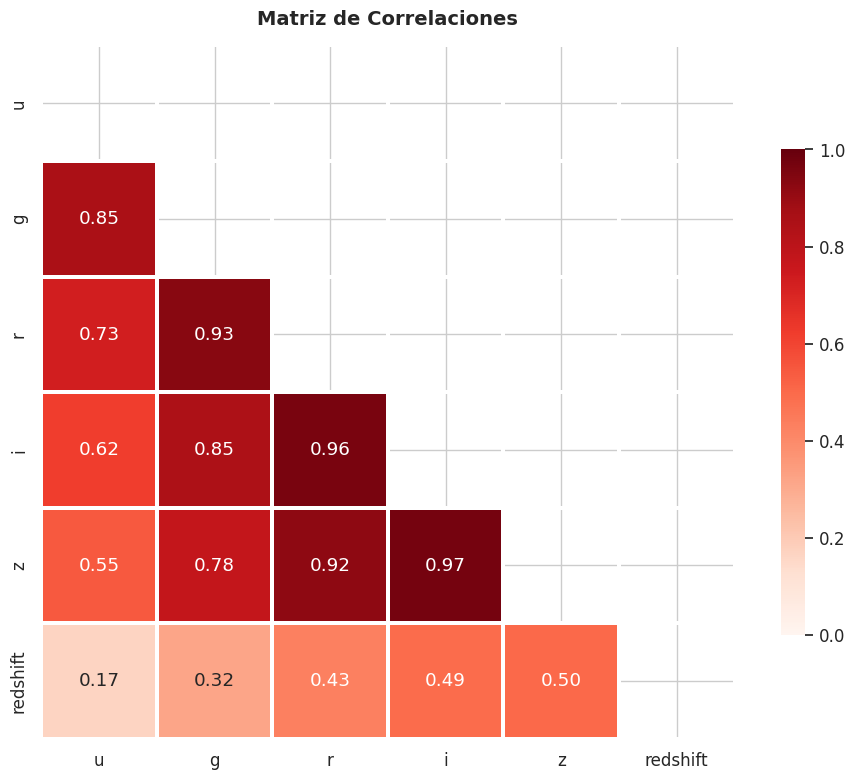

In [9]:
# Matriz de Correlaciones
corr_matrix = X_clean.corr()

# Máscara triángulo superior
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Heatmap
f, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1.0,
    square=True,
    linewidths=1.5,
    linecolor='white',
    cbar_kws={"shrink": 0.7},
    ax=ax
)

plt.title("Matriz de Correlaciones", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---  
## 1.5. Exploración para Feature Engineering

En fotometría, las magnitudes individuales ($u, g, r, i, z$) de una estrella varía según l adistancia aparente al telescopio. Para obtener propiedades físicas intrínsecas (como la temperatura espectral) independientes de la distancia, se restan las magnitudes entre sí creando **Índices de Color**.

Se construyen 4 nuevas variables sintéticas:

* Índice UV-Verde:$\quad u\_g = u - g$
* Índice Verde-Rojo:$\quad g\_r = g - r$
* Índice Rojo-Infrarrojo:$\quad r\_i = r - i$
* Índice Infrarrojo Cercano-Lejano:$\quad i\_z = i - z$

Los gráficos de dispersión bivariados (ej. $u\_g$ vs $g\_r$, conocidos como Diagramas Color-Color) revelan cúmulos aislados de poblaciones estelares frente a objetos extragalácticos de forma mucho más nítida que las magnitudes absolutas.

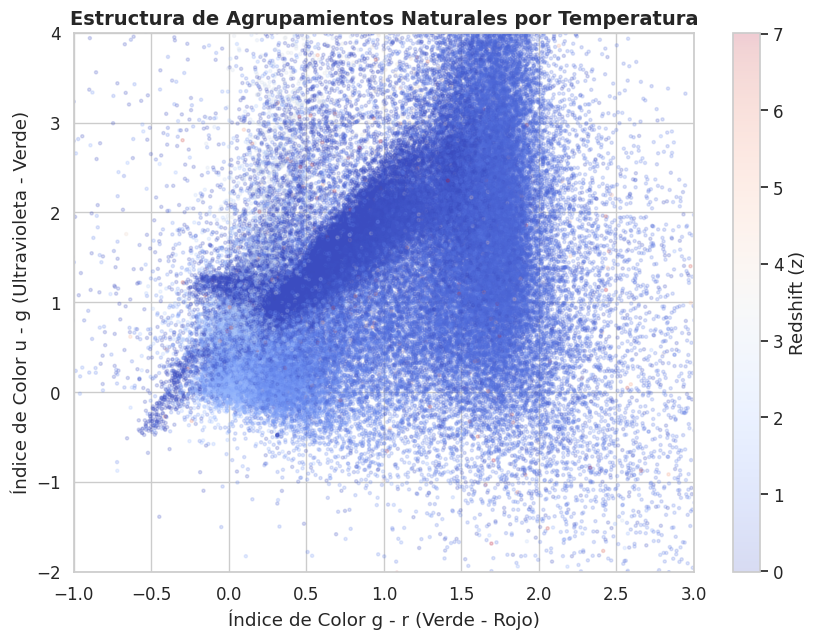

In [10]:
# Creación de Índices de Color
X_colors = X_clean.copy()
X_colors['u_g'] = X_colors['u'] - X_colors['g']
X_colors['g_r'] = X_colors['g'] - X_colors['r']
X_colors['r_i'] = X_colors['r'] - X_colors['i']
X_colors['i_z'] = X_colors['i'] - X_colors['z']

# Graficar Diagrama Color-Color (u-g vs g-r)
plt.figure(figsize=(10, 7))
plt.scatter(X_colors['g_r'], X_colors['u_g'], alpha=0.2, s=5, c=X_colors['redshift'], cmap='coolwarm')
plt.colorbar(label='Redshift (z)')
plt.xlim(-1, 3)
plt.ylim(-2, 4)
plt.xlabel("Índice de Color g - r (Verde - Rojo)")
plt.ylabel("Índice de Color u - g (Ultravioleta - Verde)")
plt.title("Estructura de Agrupamientos Naturales por Temperatura", fontsize=14, fontweight='bold')
plt.show()

El gráfico de dispersión ($u-g$ vs $g-r$) confirma visualmente la utilidad de las nuevas variables:

* **Separación Estructural en Agrupaciones Estelares:** En lugar de una nube de datos uniforme, la representación de los índices de color hace que surjan estructuras bien definidas. Se observa una concentración principal (azul oscuro) que traza una curva característica desde la zona inferior izquierda ($g-r \approx -0.5, u-g \approx -0.5$) ascendiendo hacia la derecha ($g-r \approx 1.5, u-g \approx 3.0$).
* **Discriminación Térmica:**
  * Los objetos situados en la región inferior izquierda (valores bajos de $g-r$ y $u-g$) corresponden a cuerpos con emisión dominante en bandas de alta energía (ultravioleta/azul), representando **fuentes de muy alta temperatura** (estrellas calientes de tipo O/B y cuásares).
  * La región superior derecha alberga cuerpos con valores de $g-r$ y $u-g$ elevados, identificando **objetos fríos o enrojecidos** por presencia de polvo (estrellas de baja masa M/K o galaxias elípticas evolucionadas).
* **Comportamiento del `redshift` ($z$):** La barra de color lateral muestra que la inmensa mayoría de la masa central de datos presenta un $z \approx 0$ (población estelar de la Vía Láctea y galaxias locales). Sin embargo, los puntos de tonos rojizos/rosados ($z > 3$), correspondientes a cuásares lejanos, aparecen dispersos fuera de la concentración central, lo que muestra que los índices de color permiten aislar este tipo de objetos extremos.
* **Aportación al Clustering:** Esta formación natural de conglomerados de distinta densidad evidencia que la transformación logarítmica de resta de magnitudes ($\frac{f_u}{f_g}$) provee fronteras más claras para que algoritmos no supervisados (K-Means, DBSCAN, GMM) identifiquen agrupaciones físicas reales.

---  
## 1.6. Evaluación para la Selección del Escalado

Evaluación de la magnitud de las escalas de cada variable para definir la estrategia de normalización/escalado.

#### `RobustScaler` frente a `MinMaxScaler` / `StandardScaler`:
1. **Problema de `MinMaxScaler`:** Escala en un rango estricto $[0, 1]$ basándose en los valores mínimo y máximo. Debido a los *outliers* de alto `redshift` ($z > 3$), el $99\%$ de las estrellas y galaxias concentradas en $z \approx 0$ se comprimirían en un rango minúsculo ($[0, 0.05]$), perdiendo toda la resolución métrica.
2. **Problema de `StandardScaler`:** Se basa en la media ($\bar{x}$) y desviación estándar ($s_x$), métricas fuertemente distorsionadas por la asimetría de `redshift`.
3. **Elección de `RobustScaler`:**
   $$x_{\text{scaled}} = \frac{x - \text{Mediana}(x)}{IQR} = \frac{x - Q_2}{Q_3 - Q_1}$$
   Restar la mediana y dividir por el Rango Intercuartílico ($IQR$) garantiza que la estructura central de las estrellas y galaxias permanezca escalada e insensible a las colas extremas de los cuásares.

In [11]:
# Comparación de rangos
ranges = pd.DataFrame({
    'Mínimo': X_clean.min(),
    'Mediana (Q2)': X_clean.median(),
    'Máximo': X_clean.max(),
    'IQR (Q3 - Q1)': X_clean.quantile(0.75) - X_clean.quantile(0.25)
})

print("--- Comparación de Escalas y Rangos Intercuartílicos (IQR) ---")
display(ranges)

--- Comparación de Escalas y Rangos Intercuartílicos (IQR) ---


,Mínimo,Mediana (Q2),Máximo,IQR (Q3 - Q1)
u,10.996230,22.179140,32.781390,3.335070
g,10.498200,21.099930,31.602240,3.158535
r,9.822070,20.125310,29.571860,2.908995
i,9.469903,19.405150,32.141470,2.664230
z,9.612333,19.004600,29.383740,2.460290
redshift,-0.009971,0.424176,7.011245,0.649650


---  
## 1.7. Conclusiones para la Fase de Preprocesamiento

Tras finalizar el Análisis Exploratorio de Datos, se definen las siguientes decisiones metodológicas para el pipeline de preprocesamiento:

1. **Eliminar Metadatos:** Se descartarán las 11 columnas de identificadores (`obj_ID`, `alpha`, `delta`, `run_ID`, etc.) por carecer de poder discriminante astronómico.
2. **Ocultar Etiqueta Target:** Se aislará la columna `class` para mantener el clustering 100% no supervisado.
3. **Filtro de Calidad:** Se eliminarán los registros con magnitudes fotométricas $\le 0$ por errores de saturación del CCD.
4. **Ingeniería de Características:** Se incluirán los 4 **Índices de Color** ($u-g$, $g-r$, $r-i$, $i-z$) para capturar la temperatura intrínseca de los cuerpos celestes.
5. **Escalado Robusto:** Se aplicará `RobustScaler` sobre las 10 variables resultantes para proteger las distancias euclidianas frente a los *outliers* de alto *redshift*.
6. **Reducción PCA:** Se aplicará PCA sobre los datos escalados para solventar la colinealidad de $r \ge 0.95$ previa a la fase de clustering.